In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import os

# --- Keras/TensorFlow 相关的文本处理工具 ---
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# --- Keras/TensorFlow 模型构建模块 ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, LSTM

In [2]:
# --- 中文字体设置 (可选，确保中文显示正常) ---
try:
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS'] 
    plt.rcParams['axes.unicode_minus'] = False 
except:
    pass

In [3]:
# --- 文件路径 ---
TRAIN_FILE_PATH = './review/drugsComTrain_raw.csv'
TEST_FILE_PATH = './review/drugsComTest_raw.csv'


def map_rating_to_sentiment(rating):
    """
    将 1-10 的评分映射到 -1, 0, 1 三个情感类别:
    -1: Negative (1-4)
    0: Neutral (5-6)
    1: Positive (7-10)
    """
    if rating <= 4:
        return -1  # 消极
    elif rating <= 6:
        return 0  # 中性
    else:
        return 1  # 积极


# ----------------------------------------
# (1) 读取原始数据, (2) 提取“评分”一列
# ----------------------------------------

print("--- 训练集数据处理 ---")
# 1. 读取原始数据 
train_data = pd.read_csv(TRAIN_FILE_PATH)
    
# 2. 提取“评分”一列 
train_rating = train_data['rating']
    
# ----------------------------------------
# (3) 根据评分确定情感标签 (-1, 0, 1)
# ----------------------------------------
print("3. 根据评分确定情感标签 (-1=消极, 0=中性, 1=积极)...")
train_label = train_rating.apply(map_rating_to_sentiment)
    
print(f"训练集原始数据量: {len(train_data)}")
print(f"训练集标签分布:\n{train_label.value_counts()}")


print("\n--- 测试集数据处理 ---")

# 测试集处理类似，自行完成
test_data = pd.read_csv(TEST_FILE_PATH)
test_rating = test_data['rating']
    
print("3. 根据评分确定情感标签 (-1=消极, 0=中性, 1=积极)...")
test_label = test_rating.apply(map_rating_to_sentiment)

print(f"测试集原始数据量: {len(test_data)}")
print(f"测试集标签分布:\n{test_label.value_counts()}")

--- 训练集数据处理 ---
3. 根据评分确定情感标签 (-1=消极, 0=中性, 1=积极)...
训练集原始数据量: 161297
训练集标签分布:
rating
 1    106866
-1     40075
 0     14356
Name: count, dtype: int64

--- 测试集数据处理 ---
3. 根据评分确定情感标签 (-1=消极, 0=中性, 1=积极)...
测试集原始数据量: 53766
测试集标签分布:
rating
 1    35440
-1    13497
 0     4829
Name: count, dtype: int64



--- 标签分布统计 ---
训练集标签分布:
rating
 1    106866
-1     40075
 0     14356
Name: count, dtype: int64
测试集标签分布:
rating
 1    35440
-1    13497
 0     4829
Name: count, dtype: int64


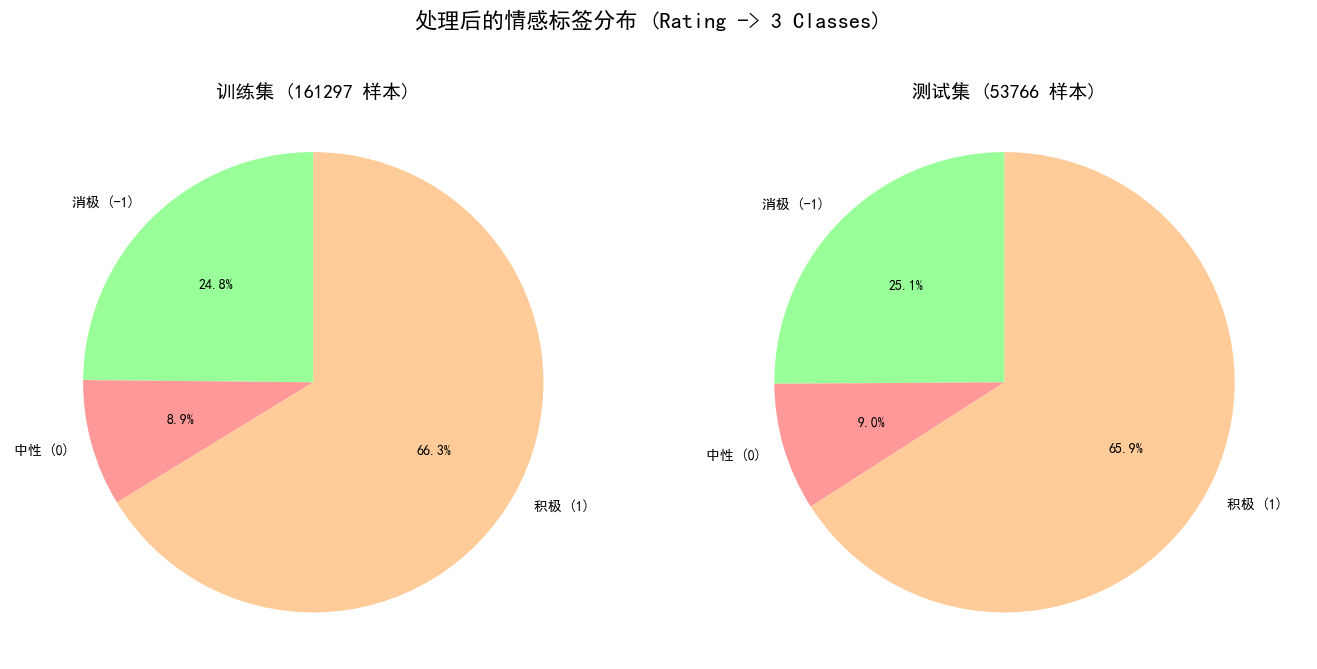


✅ 情感标签扇形图已保存到: output2.0\sentiment_label_distribution.png


In [4]:
def generate_sentiment_labels(file_path):
    """加载数据并生成情感标签"""
    try:
        data = pd.read_csv(file_path)
        # 清除 rating 或 review 缺失的行，尽管本步骤只关注 rating
        data = data.dropna(subset=['rating']) 
        rating = data['rating']
        label = rating.apply(map_rating_to_sentiment)
        return label
    except FileNotFoundError:
        print(f"错误: 文件未找到，请检查路径: {file_path}")
        return None


def plot_sentiment_pie(train_label, test_label):
    """绘制训练集和测试集的情感标签扇形图"""
    
    if train_label is None or test_label is None:
        print("缺少数据，跳过绘图。")
        return

    # 统计标签计数
    train_counts = train_label.value_counts().sort_index()
    test_counts = test_label.value_counts().sort_index()
    
    # 定义标签名称和颜色
    label_names = ['消极 (-1)', '中性 (0)', '积极 (1)']
    colors = ['#ff9999', '#ffcc99', '#99ff99'] # 红色/橙色/绿色

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    fig.suptitle('处理后的情感标签分布 (Rating -> 3 Classes)', fontsize=16)

    # ------------------- 训练集扇形图 -------------------
    axes[0].pie(
        train_counts,
        labels=label_names,
        autopct='%1.1f%%',        # 显示百分比
        startangle=90,            # 从顶部开始
        colors=[colors[i] for i in train_counts.index]
    )
    axes[0].set_title(f'训练集 ({train_label.shape[0]} 样本)', fontsize=14)
    axes[0].axis('equal') # 确保饼图是圆形的

    # ------------------- 测试集扇形图 -------------------
    axes[1].pie(
        test_counts,
        labels=label_names,
        autopct='%1.1f%%',
        startangle=90,
        colors=[colors[i] for i in test_counts.index]
    )
    axes[1].set_title(f'测试集 ({test_label.shape[0]} 样本)', fontsize=14)
    axes[1].axis('equal')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # 保存图片 (可选)
    output_dir = 'output2.0'
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    save_path = os.path.join(output_dir, 'sentiment_label_distribution.png')
    plt.savefig(save_path)
    
    plt.show()
    print(f"\n✅ 情感标签扇形图已保存到: {save_path}")


# ----------------------------------------
# 执行数据加载和绘图
# ----------------------------------------
train_label_data = generate_sentiment_labels(TRAIN_FILE_PATH)
test_label_data = generate_sentiment_labels(TEST_FILE_PATH)

if train_label_data is not None and test_label_data is not None:
    print("\n--- 标签分布统计 ---")
    print(f"训练集标签分布:\n{train_label_data.value_counts()}")
    print(f"测试集标签分布:\n{test_label_data.value_counts()}")
    plot_sentiment_pie(train_label_data, test_label_data)

In [5]:
# --- 超参数定义 ---
# 假设词汇表大小，需要根据实际数据分析确定，这里给一个合理的假设值
WORDS = 60000 
# 假设最大序列长度，需要根据实际数据分析确定
LENGTH = 200

# ----------------------------------------
# (1) 提取“评论”一列
# ----------------------------------------
print("\n--- 1. 提取评论列 ---")
# 确保 train_review 是字符串类型
train_review = train_data['review'].astype(str)
test_review = test_data['review'].astype(str)

print(f"训练集评论总数: {len(train_review)}")
print(f"第一句话长度 (单词数，未分词): {len(train_review.iloc[0].split())}")

# ----------------------------------------
# (2) 将文本序列化 (构建词汇表并转换为整数序列)
# ----------------------------------------
print("\n--- 2. 文本序列化 (Tokenizer) ---")

# 初始化 Tokenizer
# num_words=WORDS 表示只考虑最常见的 WORDS 个单词
tokenizer = Tokenizer(num_words=WORDS) 

# 在训练集上拟合 Tokenizer (构建词汇表)
# ❗ 关键：Tokenizer 必须仅基于训练集文本 fit
tokenizer.fit_on_texts(train_review)

# 将文本转换为整数序列
train_sequence = tokenizer.texts_to_sequences(train_review)
test_sequence = tokenizer.texts_to_sequences(test_review) # 测试集使用训练集的 tokenizer

print(f"词汇表大小 (Vocabulary Size): {len(tokenizer.word_index)} (考虑前 {WORDS} 个)")
print(f"训练集第一句话序列化后长度: {len(train_sequence[0])}")
print(f"训练集序列总数: {len(train_sequence)}")

# ----------------------------------------
# (3) 将序列化后的文本填充并形成等长序列
# ----------------------------------------
print("\n--- 3. 序列填充/截断 (Padding) ---")

# 将序列填充或截断至 LENGTH (参考 image_f77c9c.png)
# 默认 post padding，即在序列末尾补零
x_train = pad_sequences(train_sequence, maxlen=LENGTH)
x_test = pad_sequences(test_sequence, maxlen=LENGTH)

print(f"x_train 形状: {x_train.shape}")
print(f"x_test 形状: {x_test.shape}")
print(f"训练集第一句话填充/截断后: {x_train[0]}")


# ----------------------------------------
# (4) 将标签形成独热编码 (One-Hot Encoding)
# ----------------------------------------
print("\n--- 4. 标签独热编码 (One-Hot Encoding) ---")

# ❗ 修正标签：将 [-1, 0, 1] 转换为 [0, 1, 2] 以适应 to_categorical
# 0: Negative, 1: Neutral, 2: Positive
train_label_mapped = train_label + 1
test_label_mapped = test_label + 1

# 将标签转换为独热编码 (参考 image_f77c81.png)
# num_classes=3 是因为有 消极(-1/0), 中性(0/1), 积极(1/2) 三类
y_train = to_categorical(train_label_mapped, num_classes=3)
y_test = to_categorical(test_label_mapped, num_classes=3)

print(f"y_train 形状: {y_train.shape}")
print(f"y_test 形状: {y_test.shape}")
print(f"训练集第一个标签 (原始: {train_label.iloc[0]}) 独热编码后: {y_train[0]}")


# ----------------------------------------
# 可视化 (独热编码和 Tokenizer)
# ----------------------------------------

# 可视化独热编码后的标签 (前5个)
print("\n--- 可视化独热编码后的标签 (前5个) ---")
print(pd.DataFrame(y_train[:10], columns=['Negative', 'Neutral', 'Positive']))

# 可视化 Tokenizer 词汇表 (前10个)
print("\n--- 可视化 Tokenizer 词汇表 (前10个) ---")
# 注意：词汇表索引从 1 开始（0 保留给 padding）
top_words = list(tokenizer.word_index.items())[:10]
print("词语 | 索引")
print("-" * 12)
for word, index in top_words:
    print(f"{word:<5} | {index}")


--- 1. 提取评论列 ---
训练集评论总数: 161297
第一句话长度 (单词数，未分词): 17

--- 2. 文本序列化 (Tokenizer) ---
词汇表大小 (Vocabulary Size): 51429 (考虑前 60000 个)
训练集第一句话序列化后长度: 17
训练集序列总数: 161297

--- 3. 序列填充/截断 (Padding) ---
x_train 形状: (161297, 200)
x_test 形状: (53766, 200)
训练集第一句话填充/截断后: [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0 

In [6]:
print("\n--- 可视化前 5 句评论的序列化结果 ---")
print(f"最大序列长度 (LENGTH): {LENGTH}")
print("索引值 0 代表填充符 (<pad>)。")
print("-" * 70)

# 提取前 5 个样本
for i in range(5):
    # 原始序列 (未填充/截断)
    original_seq = train_sequence[i]
    original_len = len(original_seq)
    
    # 填充/截断后的序列
    padded_seq = x_train[i]
    padded_len = len(padded_seq) # 应该等于 LENGTH

    print(f"样本 {i+1}:")
    print(f"  原始单词数: {original_len}")
    print(f"  填充后长度: {padded_len}")
    
    # 打印序列的前15个和后15个索引，以展示填充效果
    print(f"  序列 (前15): {padded_seq[:15]}")
    
    # 如果序列长度大于 15，展示后15个
    if padded_len > 15:
        print(f"  序列 (后15): {padded_seq[-15:]}")
    
    print("-" * 70)


--- 可视化前 5 句评论的序列化结果 ---
最大序列长度 (LENGTH): 200
索引值 0 代表填充符 (<pad>)。
----------------------------------------------------------------------
样本 1:
  原始单词数: 17
  填充后长度: 200
  序列 (前15): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
  序列 (后15): [  28   35  197    1   45    5   15  848   12 2922   99  150    2 3806
 1551]
----------------------------------------------------------------------
样本 2:
  原始单词数: 142
  填充后长度: 200
  序列 (前15): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
  序列 (后15): [ 73 262  11 134 221 248 417   2  24 170  14  19   3 212 312]
----------------------------------------------------------------------
样本 3:
  原始单词数: 139
  填充后长度: 200
  序列 (前15): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
  序列 (后15): [  11  100  115   35   43    3  973   12  168   80  387   10   24 9919
 8144]
----------------------------------------------------------------------
样本 4:
  原始单词数: 93
  填充后长度: 200
  序列 (前15): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
  序列 (后15): [105  18 184  83 182 140 118 115 106  20  15 266  21   3 449]
------------------

In [7]:
from tensorflow.keras.metrics import Recall, Precision
# --- 超参数定义 (沿用前文的 WORDS 和 LENGTH) ---
# 词嵌入的维度 (Embedding Dimension) 和 LSTM 单元数
DEPTH = 128 


print("\n--- 5. 搭建 LSTM 情感分析模型 ---")

# (1) 初始化 Sequential 模型
model = Sequential()

# (2) 嵌入层 (Embedding Layer)
# WORDS: 词汇表大小 (输入最大索引 + 1)
# DEPTH: 每个词语嵌入向量的维度
# input_length: 输入序列的固定长度
model.add(Embedding(WORDS, DEPTH))

# (3) LSTM 层
# DEPTH: LSTM 单元的数量 (输出维度)
model.add(LSTM(DEPTH))

# (4) 全连接输出层 (Dense Layer)
# 3: 输出类别数 (Negative, Neutral, Positive)
# activation='softmax': 用于多分类概率输出
model.add(Dense(3, activation='softmax'))

# 假设你的输入数据 x_train 形状为 (num_samples, LENGTH)
input_data_shape = (None, LENGTH) # None 代表 batch size
model.build(input_shape=input_data_shape)

# 打印模型结构概览
model.summary()

# ----------------------------------------
print("\n--- 6. 编译模型 ---")
# 编译模型
# optimizer='rmsprop': 优化器
# loss='categorical_crossentropy': 损失函数，用于独热编码的多分类任务
# metrics=['acc']: 评估指标
# 编译模型
model.compile(
    optimizer='rmsprop', 
    loss='categorical_crossentropy', 
    metrics=[
        'acc',        # 准确率 (Accuracy)
        Recall(),     # 召回率 (Recall)
        Precision()   # 精确率 (Precision)
    ]
)

print("✅ 模型搭建与编译代码已完成。")


--- 5. 搭建 LSTM 情感分析模型 ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     7,680,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,811,971 (29.80 MB)

 Trainable params: 7,811,971 (29.80 MB)

 Non-trainable params: 0 (0.00 B)


--- 6. 编译模型 ---
✅ 模型搭建与编译代码已完成。


In [11]:
# 导入必要的模块 (用于绘图，确保您之前已经导入 matplotlib.pyplot as plt)
from matplotlib.ticker import MultipleLocator

# ----------------------------------------
# (1) 定义训练历史绘图函数
# ----------------------------------------
def plot_history(history):
    """
    绘制训练集和验证集的准确率及损失曲线。
    参数:
        history: model.fit() 返回的 History 对象。
    """
    f, ax = plt.subplots(1, 2, figsize=(16, 7))

    # 从 history 对象中获取数据
    acc = history.history['acc']
    val_acc = history.history['val_acc']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    # Keras 3 可能将 'acc' 更名为 'accuracy'，这里做兼容性检查
    if 'acc' not in history.history:
         acc = history.history['accuracy']
         val_acc = history.history['val_accuracy']

    epochs = range(1, len(acc) + 1)
    
    # --- 准确率图 ---
    plt.sca(ax[0])
    ax[0].xaxis.set_major_locator(MultipleLocator(1)) # 设置X轴刻度间隔为1
    plt.plot(epochs, acc, marker='o', label='Training acc')
    plt.plot(epochs, val_acc, marker='o', label='Validation acc')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.title('Training and validation accuracy')
    plt.grid(axis='y', linestyle='--')
    plt.legend()

    # --- 损失图 ---
    plt.sca(ax[1])
    ax[1].xaxis.set_major_locator(MultipleLocator(1))
    plt.plot(epochs, loss, marker='o', label='Training loss')
    plt.plot(epochs, val_loss, marker='o', label='Validation loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.title('Training and validation loss')
    plt.grid(axis='y', linestyle='--')
    plt.legend()
    
    plt.show()

# ----------------------------------------
# (2) 训练模型
# ----------------------------------------
print("\n--- 7. 模型训练 ---")

# 使用 model.fit 进行训练
# epochs=10: 迭代次数
# batch_size=32: 每批次处理的样本数
# validation_split=0.25: 从训练集中划分 25% 作为验证集
history = model.fit(
    x_train, 
    y_train, 
    epochs=10, 
    batch_size=64, 
    verbose=1, 
    validation_split=0.25
)
print("✅ 模型训练完成。")

--- 检查 GPU 配置 ---
❌ 未检测到 GPU。训练将在 CPU 上进行。

--- 7. 模型训练 ---
Epoch 1/10
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 383s 203ms/step - acc: 0.8500 - loss: 0.4039 - precision: 0.8833 - recall: 0.8173 - val_acc: 0.8287 - val_loss: 0.4678 - val_precision: 0.8569 - val_recall: 0.8009
Epoch 2/10
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 343s 181ms/step - acc: 0.8654 - loss: 0.3679 - precision: 0.8938 - recall: 0.8371 - val_acc: 0.8298 - val_loss: 0.4743 - val_precision: 0.8542 - val_recall: 0.8061
Epoch 3/10
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 342s 181ms/step - acc: 0.8807 - loss: 0.3294 - precision: 0.9046 - recall: 0.8570 - val_acc: 0.8394 - val_loss: 0.4525 - val_precision: 0.8630 - val_recall: 0.8171
Epoch 4/10
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 344s 182ms/step - acc: 0.8971 - loss: 0.2890 - precision: 0.9168 - recall: 0.8788 - val_acc: 0.8427 - val_loss: 0.4611 - val_precision: 0.8645 - val_recall: 0.8219
Epoch 5/10
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 337s 178ms/step - acc: 0.9131 - loss: 0.2489 - precision: 0.9280 - recall:


--- 8. 模型评估 ---
1681/1681 ━━━━━━━━━━━━━━━━━━━━ 61s 37ms/step - acc: 0.8613 - loss: 0.6211 - precision: 0.8676 - recall: 0.8555

--- 评估结果 ---
测试集损失 (Test Loss): 0.6211
测试集准确率 (Test Accuracy): 0.8613

--- 9. 训练历史可视化 ---


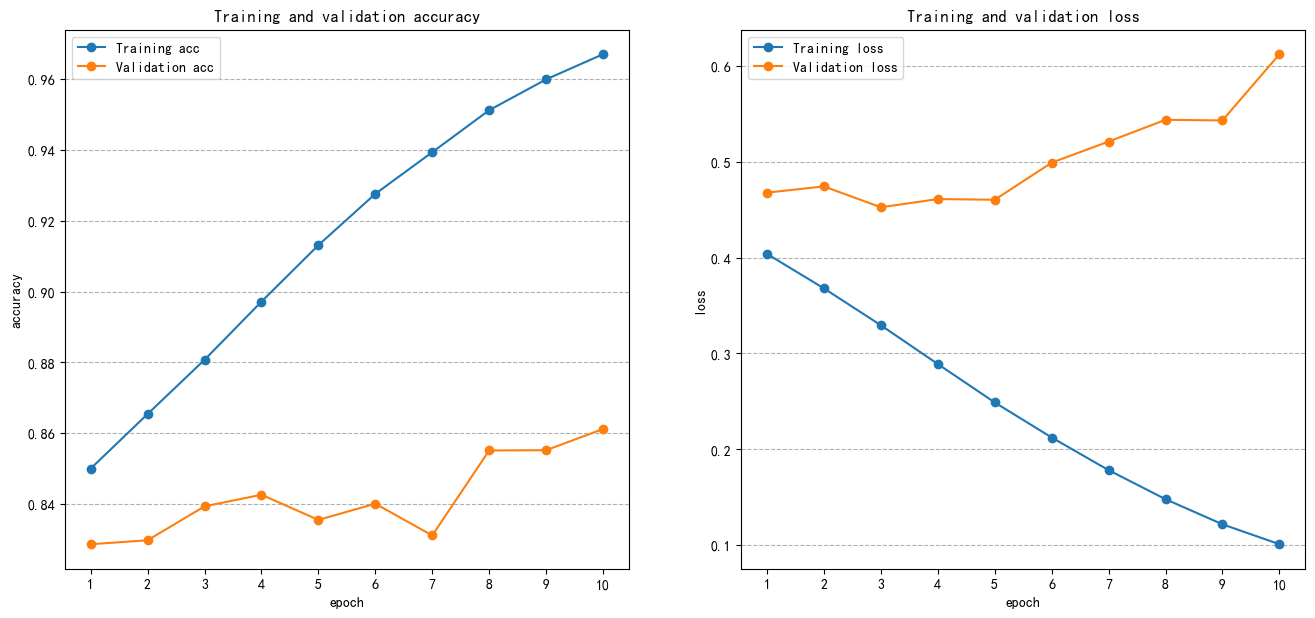

In [13]:
# ----------------------------------------
# (2) 评估模型 (修正了解包 ValueError 的问题)
# ----------------------------------------
print("\n--- 8. 模型评估 ---")

# 使用 model.evaluate 在独立的测试集上评估模型性能
# 注意：model.evaluate 返回的指标数量 = 1 (损失) + metrics 的数量
test_results = model.evaluate(
    x_test, 
    y_test, 
    verbose=1
)

# 假设您的 metrics 是 ['acc', Recall(), Precision()]，那么返回 4 个值
# 我们统一使用列表捕获，避免 ValueError
test_loss = test_results[0]
test_acc = test_results[1] 

print(f"\n--- 评估结果 ---")
print(f"测试集损失 (Test Loss): {test_loss:.4f}")
print(f"测试集准确率 (Test Accuracy): {test_acc:.4f}")

# ----------------------------------------
# (3) 绘图
# ----------------------------------------
print("\n--- 9. 训练历史可视化 ---")
# 确保 history 对象已通过 model.fit 获得
plot_history(history)